# Courtship song — paper-ready figures

Per paired courtship bout this notebook answers four questions:

1. Which fly is the male? (the singer — Drosophila courtship song is male-produced)
2. What song types is he performing? (pulse / sine / waggle / quiet)
3. What are his walking patterns during singing? (forward speed, turn rate, walking vs stopped)
4. How does his center-of-mass height change across song types?

Data source: the post-rescue relinked h5 produced by `rescue_identity_relink_inplace.py`.
All reusable logic lives in `utils/song_analysis.py`, `utils/sex_id.py`, `utils/locomotion.py`.
The sandbox notebook `Courtship_Song_Analysis.ipynb` is untouched; this is a clean sibling.


In [14]:
# --- Setup: imports + matplotlib style + output dir ---
from __future__ import annotations

import os, sys, pickle, warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

# Project imports (notebook runs from the repo root OR from notebooks/)
REPO_ROOT = Path('.').resolve()
if not (REPO_ROOT / 'utils').exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from utils.io_dict_to_hdf5 import load as h5_load
from utils.pair_validity import PairValidityConfig, compute_pair_validity
from utils.song_analysis import SongAnalysisConfig, analyze_fly_song
from utils.sex_id import SexIdConfig, identify_male_female
from utils.locomotion import (
    LocomotionConfig,
    compute_centroid_velocity,
    compute_com_height,
    classify_walking_state,
    summarize_by_song,
    walking_fraction,
)

# Paper-ready matplotlib defaults: Type-1 / sans-serif / clean spines
mpl.rcParams.update({
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Arial', 'Helvetica'],
    'font.size': 8,
    'axes.labelsize': 8,
    'axes.titlesize': 9,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'axes.spines.right': False,
    'axes.spines.top': False,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.transparent': False,
})

# Colors shared across figures
SONG_COLORS = {
    'pulse':  '#d62728',  # red
    'sine':   '#1f77b4',  # blue
    'waggle': '#9467bd',  # purple
    'quiet':  '#bdbdbd',  # grey
}
FLY_COLORS = {'fly0': '#ff7f0e', 'fly1': '#2ca02c'}

FIG_DIR = REPO_ROOT / 'figures' / 'courtship'
FIG_DIR.mkdir(parents=True, exist_ok=True)

H5_PATH = Path('/data2/users/eabe/datasets/Johnson_lab/courtship/04092026_bouts/'
               'Data_analysis/analysis/v1/'
               'ik_output_combined_v1_courtship_both_relinked.h5')

CACHE_PATH = FIG_DIR / 'per_bout_cache.pkl'

print(f'repo   : {REPO_ROOT}')
print(f'h5     : {H5_PATH}')
print(f'figures: {FIG_DIR}')


repo   : /home/eabe/Research/MyRepos/3d_tracking_dataset
h5     : /data2/users/eabe/datasets/Johnson_lab/courtship/04092026_bouts/Data_analysis/analysis/v1/ik_output_combined_v1_courtship_both_relinked.h5
figures: /home/eabe/Research/MyRepos/3d_tracking_dataset/figures/courtship


In [15]:
# --- Load the relinked h5 and pair fly0/fly1 bouts ---
# Each bout key in this h5 holds ONE fly's kp_data / xpos_egocentric / qpos.
# The pairing is consecutive (fly0, fly1) and validated by info['source_flies'].

def _pair_bouts(bout_keys, info):
    """Copy of scripts/rescue_identity_relink_inplace._pair_bouts."""
    src = list(info.get('source_flies', []))
    bucket = list(info.get('bucket', []))
    pairs = []
    if src and len(src) == len(bout_keys):
        i = 0
        while i + 1 < len(bout_keys):
            if (src[i] == 'fly0' and src[i + 1] == 'fly1'
                    and (not bucket or bucket[i] == 'both' == bucket[i + 1])):
                pairs.append((bout_keys[i], bout_keys[i + 1]))
                i += 2
            else:
                i += 1
    else:
        for i in range(0, len(bout_keys) - 1, 2):
            pairs.append((bout_keys[i], bout_keys[i + 1]))
    return pairs


print('loading h5 (slow — full file)...')
data = h5_load(str(H5_PATH))
info = data.get('info', {}) or {}
kp_names = list(info['kp_names'])
bout_keys = [k for k in data.keys() if k != 'info']
# bouts are written in order; keep that order
bout_keys.sort()

pairs = _pair_bouts(bout_keys, info)
print(f'bouts: {len(bout_keys)}  pairs: {len(pairs)}  kp: {len(kp_names)}')
print(f'first 3 pairs: {pairs[:3]}')


loading h5 (slow — full file)...
bouts: 298  pairs: 149  kp: 50
first 3 pairs: [('bout_000', 'bout_001'), ('bout_002', 'bout_003'), ('bout_004', 'bout_005')]


In [16]:
# --- Run the full per-pair analysis and cache to a pickle ---
# Set FORCE=True to invalidate the cache and re-run from scratch.
FORCE = False

song_cfg = SongAnalysisConfig()
sex_cfg  = SexIdConfig()
loc_cfg  = LocomotionConfig()
pair_cfg = PairValidityConfig()


def _get_fields(bout):
    """Return kp_world (T, N, 3), xpos_ego (T, N, 3) or None, qpos (T, D) or None.

    Each bout key in the relinked h5 holds ONE fly's data — no fly0_/fly1_
    prefixes. kp_data is always present; xpos_egocentric / qpos may be
    absent on older bouts.
    """
    kp = np.asarray(bout['kp_data'])
    if kp.ndim == 2:
        kp = kp.reshape(kp.shape[0], -1, 3)
    xp = bout.get('xpos_egocentric')
    if xp is not None:
        xp = np.asarray(xp)
        if xp.ndim == 2:
            xp = xp.reshape(xp.shape[0], -1, 3)
    qp = bout.get('qpos')
    if qp is not None:
        qp = np.asarray(qp)
    return kp, xp, qp


def _analyze_pair(key0, key1, bout0, bout1):
    kp0, xp0, q0 = _get_fields(bout0)
    kp1, xp1, q1 = _get_fields(bout1)

    # Clip to common length (should already match, but be defensive)
    T = min(len(kp0), len(kp1))
    kp0, kp1 = kp0[:T], kp1[:T]
    if xp0 is not None: xp0 = xp0[:T]
    if xp1 is not None: xp1 = xp1[:T]
    if q0  is not None: q0  = q0[:T]
    if q1  is not None: q1  = q1[:T]

    # Joint pair validity: colocation already handled inside via
    # cfg.min_pair_separation_mm (set on PairValidityConfig).
    pv = compute_pair_validity(kp0, kp1, kp_names, cfg=pair_cfg)
    v0 = np.asarray(pv['valid_fly0']).astype(bool)
    v1 = np.asarray(pv['valid_fly1']).astype(bool)
    coloc = np.asarray(pv['pair_colocated']).astype(bool)

    # Song analysis for both flies (summary computed over valid frames)
    song0 = analyze_fly_song(kp0, xp0, q0, kp_names, cfg=song_cfg, valid_mask=v0)
    song1 = analyze_fly_song(kp1, xp1, q1, kp_names, cfg=song_cfg, valid_mask=v1)

    # Male/female assignment
    sex = identify_male_female(song0, song1, kp0, kp1, kp_names, cfg=sex_cfg)

    # Locomotion for MALE only
    if sex['male_id'] == 'fly0':
        male_kp, male_song, male_valid = kp0, song0, v0
    else:
        male_kp, male_song, male_valid = kp1, song1, v1
    bl = sex['body_length_male'] if np.isfinite(sex['body_length_male']) else None
    kin = compute_centroid_velocity(male_kp, kp_names, loc_cfg, body_length=bl)
    com_z, floor_z = compute_com_height(male_kp, kp_names, loc_cfg)
    speed_bl = kin.get('speed_bl', kin['speed'])
    wstate = classify_walking_state(np.asarray(speed_bl), loc_cfg)

    # Dominant-wing frame labels for the male
    dw = str(male_song.get('dominant_wing', 'L')).upper()
    side_key = 'L' if dw.startswith('L') else 'R'
    song_labels = np.asarray(male_song['sides'][side_key]['frame_labels'])

    # Song-conditioned aggregates
    metrics = {
        'forward_speed_bl': np.asarray(kin.get('forward_speed_bl', kin['forward_speed'])),
        'speed_bl':         np.asarray(speed_bl),
        'turn_rate':        np.asarray(kin['turn_rate']),
        'com_z':            np.asarray(com_z),
    }
    by_song = summarize_by_song(song_labels, metrics, valid_mask=male_valid)

    return {
        'key0': key0, 'key1': key1,
        'T': T,
        'valid_fly0': v0, 'valid_fly1': v1, 'colocated': coloc,
        'song0': song0, 'song1': song1,
        'sex': sex,
        'male_labels': song_labels,
        'male_valid':  male_valid,
        'kin': kin,
        'com_z': com_z, 'floor_z': floor_z,
        'walking_state': wstate,
        'by_song': by_song,
    }


if CACHE_PATH.exists() and not FORCE:
    print(f'loading cache: {CACHE_PATH}')
    with open(CACHE_PATH, 'rb') as f:
        results = pickle.load(f)
else:
    results = []
    for i, (k0, k1) in enumerate(pairs):
        try:
            r = _analyze_pair(k0, k1, data[k0], data[k1])
            r['pair_idx'] = i
            results.append(r)
        except Exception as e:
            print(f'  pair {i} ({k0}/{k1}): {type(e).__name__}: {e}')
        if (i + 1) % 25 == 0:
            print(f'  processed {i + 1}/{len(pairs)}')
    with open(CACHE_PATH, 'wb') as f:
        pickle.dump(results, f)
    print(f'cached {len(results)} pair results → {CACHE_PATH}')

print(f'ok: {len(results)} pair results loaded')


loading cache: /home/eabe/Research/MyRepos/3d_tracking_dataset/figures/courtship/per_bout_cache.pkl
ok: 149 pair results loaded


In [17]:
# --- Build a per-bout results dataframe for figures + CSV export ---
def _frac(labels, valid):
    labels = np.asarray(labels); valid = np.asarray(valid, dtype=bool)
    n = int(valid.sum())
    if n == 0:
        return {k: float('nan') for k in ('pulse', 'sine', 'waggle', 'quiet')}
    sel = labels[valid]
    return {k: float(np.mean(sel == k)) for k in ('pulse', 'sine', 'waggle', 'quiet')}

rows = []
for r in results:
    sex = r['sex']
    fr  = _frac(r['male_labels'], r['male_valid'])
    bs  = r['by_song']
    row = {
        'pair_idx':           r['pair_idx'],
        'key0':               r['key0'],
        'key1':               r['key1'],
        'T':                  r['T'],
        'male_id':            sex['male_id'],
        'female_id':          sex['female_id'],
        'criterion':          sex['criterion'],
        'confidence':         sex['confidence'],
        'disagree_bodylen':   sex['disagree'],
        'song_fraction_fly0': r['song0']['summary']['song_fraction'],
        'song_fraction_fly1': r['song1']['summary']['song_fraction'],
        'body_length_male':   sex['body_length_male'],
        'body_length_female': sex['body_length_female'],
        'frac_pulse':         fr['pulse'],
        'frac_sine':          fr['sine'],
        'frac_waggle':        fr['waggle'],
        'frac_quiet':         fr['quiet'],
        'walking_fraction':   walking_fraction(r['walking_state'][r['male_valid']]) if r['male_valid'].any() else float('nan'),
        'mean_com_z':         float(np.nanmean(r['com_z'][r['male_valid']])) if r['male_valid'].any() else float('nan'),
        'mean_speed_bl':      float(np.nanmean(r['kin'].get('speed_bl', r['kin']['speed'])[r['male_valid']])) if r['male_valid'].any() else float('nan'),
    }
    # Song-conditioned aggregates
    for song in ('pulse', 'sine', 'waggle', 'quiet'):
        stats = bs.get(song, {})
        for m in ('speed_bl', 'forward_speed_bl', 'turn_rate', 'com_z'):
            row[f'{song}_{m}_mean'] = stats.get(m, {}).get('mean', float('nan'))
            row[f'{song}_{m}_n']    = stats.get(m, {}).get('n',    0)
    rows.append(row)

df = pd.DataFrame(rows)
print(df.shape)
df.head()


(149, 52)


,pair_idx,key0,key1,T,male_id,female_id,criterion,confidence,disagree_bodylen,song_fraction_fly0,...,waggle_com_z_mean,waggle_com_z_n,quiet_speed_bl_mean,quiet_speed_bl_n,quiet_forward_speed_bl_mean,quiet_forward_speed_bl_n,quiet_turn_rate_mean,quiet_turn_rate_n,quiet_com_z_mean,quiet_com_z_n
0,0,bout_000,bout_001,447,fly1,fly0,song_fraction,0.107383,False,0.892617,...,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0
1,1,bout_002,bout_003,839,fly1,fly0,song_fraction,0.023086,True,0.958284,...,0.140159,240,3.978225,16,2.115209,16,82.735527,16,0.145555,16
2,2,bout_004,bout_005,770,fly1,fly0,body_length,0.010996,False,1.000000,...,0.136105,52,NaN,0,NaN,0,NaN,0,NaN,0
3,3,bout_006,bout_007,500,fly1,fly0,song_fraction,0.314050,False,0.664000,...,0.121952,60,3.568045,16,-0.029331,16,65.763062,16,0.122930,16
4,4,bout_008,bout_009,703,fly0,fly1,song_fraction,0.164319,True,0.908962,...,0.104629,139,2.086617,64,1.996969,64,14.847166,64,0.116229,64


saved /home/eabe/Research/MyRepos/3d_tracking_dataset/figures/courtship/fig1_male_female_id.pdf


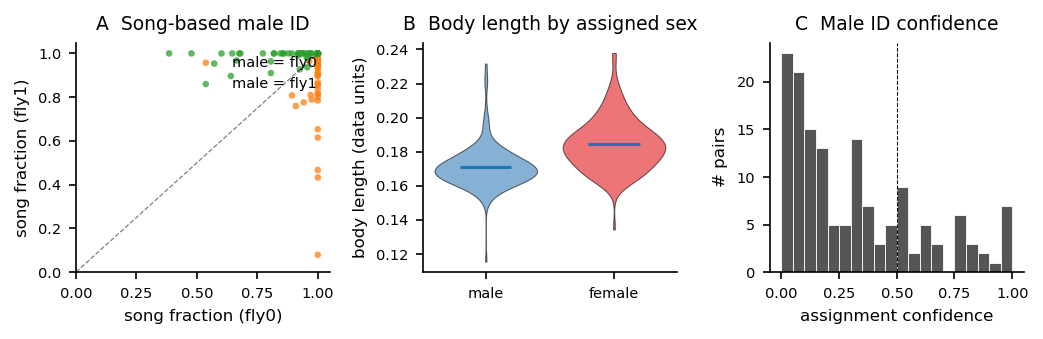

In [18]:
# --- Figure 1: Male/female identification ---
fig, axes = plt.subplots(1, 3, figsize=(7.0, 2.3))

sf0 = df['song_fraction_fly0'].values
sf1 = df['song_fraction_fly1'].values
male_is_fly0 = (df['male_id'] == 'fly0').values

# Panel A — song-fraction scatter
ax = axes[0]
ax.scatter(sf0[male_is_fly0],  sf1[male_is_fly0],  s=10,
           c=FLY_COLORS['fly0'], alpha=0.75, label='male = fly0',
           edgecolor='none')
ax.scatter(sf0[~male_is_fly0], sf1[~male_is_fly0], s=10,
           c=FLY_COLORS['fly1'], alpha=0.75, label='male = fly1',
           edgecolor='none')
ax.plot([0, 1], [0, 1], '--', color='k', lw=0.6, alpha=0.5)
ax.set_xlim(0, max(0.05, float(np.nanmax(sf0)) * 1.05))
ax.set_ylim(0, max(0.05, float(np.nanmax(sf1)) * 1.05))
ax.set_xlabel('song fraction (fly0)')
ax.set_ylabel('song fraction (fly1)')
ax.set_title('A  Song-based male ID')
ax.legend(frameon=False, loc='upper right')

# Panel B — body length by assigned sex
ax = axes[1]
bl_m = df['body_length_male'].values
bl_f = df['body_length_female'].values
bl_m = bl_m[np.isfinite(bl_m)]
bl_f = bl_f[np.isfinite(bl_f)]
parts = ax.violinplot([bl_m, bl_f], positions=[0, 1], widths=0.8,
                      showmeans=True, showextrema=False)
for pc, col in zip(parts['bodies'], ['#377eb8', '#e41a1c']):
    pc.set_facecolor(col); pc.set_alpha(0.6); pc.set_edgecolor('k'); pc.set_linewidth(0.5)
ax.set_xticks([0, 1]); ax.set_xticklabels(['male', 'female'])
ax.set_ylabel('body length (data units)')
ax.set_title('B  Body length by assigned sex')

# Panel C — confidence histogram
ax = axes[2]
ax.hist(df['confidence'].values, bins=np.linspace(0, 1, 21),
        color='#555555', edgecolor='white', linewidth=0.4)
ax.axvline(0.5, color='k', lw=0.5, ls='--')
ax.set_xlabel('assignment confidence')
ax.set_ylabel('# pairs')
ax.set_title('C  Male ID confidence')

plt.tight_layout()
out = FIG_DIR / 'fig1_male_female_id.pdf'
plt.savefig(out)
print(f'saved {out}')
plt.show()


example pair_idx=73 keys=bout_146/bout_147 male=fly0
saved /home/eabe/Research/MyRepos/3d_tracking_dataset/figures/courtship/fig2_song_example.pdf


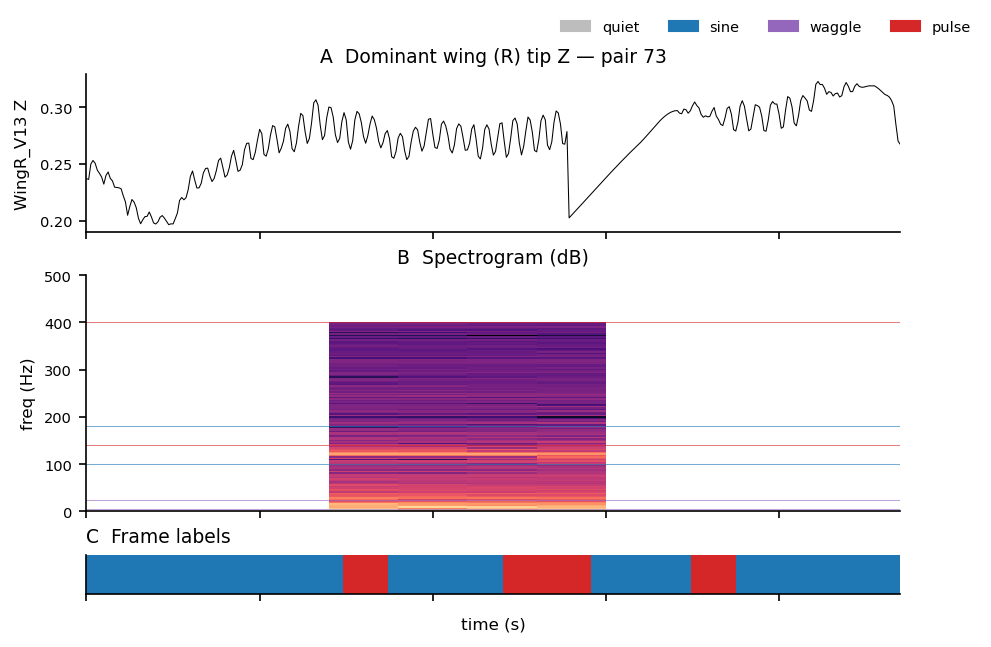

In [31]:
# --- Figure 2: Song classification example bout ---
# Pick a bout with plenty of pulse + sine activity
score = df['frac_pulse'] + df['frac_sine']
example_idx = 73 #int(score.idxmax())
ex = results[example_idx]
print(f'example pair_idx={example_idx} keys={ex["key0"]}/{ex["key1"]} '
      f'male={ex["sex"]["male_id"]}')

fs = song_cfg.fs
male_song = ex['song0'] if ex['sex']['male_id'] == 'fly0' else ex['song1']
dw = str(male_song.get('dominant_wing', 'L')).upper()
side_key = 'L' if dw.startswith('L') else 'R'
tip_key = song_cfg.left_tip if side_key == 'L' else song_cfg.right_tip
z = np.asarray(male_song['wing_data'][tip_key]['z'])
labels = ex['male_labels']
T = len(z)
t = np.arange(T) / fs

fig = plt.figure(figsize=(7.0, 4.5))
gs = fig.add_gridspec(3, 1, height_ratios=[1.2, 1.8, 0.3], hspace=0.3)

# Panel A — wing tip Z trace
axA = fig.add_subplot(gs[0])
axA.plot(t, z, lw=0.5, color='k')
axA.set_ylabel(f'{tip_key} Z')
axA.set_title(f'A  Dominant wing ({side_key}) tip Z — pair {example_idx}')
axA.set_xlim(t[0], t[-1])
axA.set_xticklabels([])

# Panel B — spectrogram
from scipy.signal import spectrogram
f_s, t_s, Sxx = spectrogram(z - np.mean(z), fs=fs, nperseg=256,
                             noverlap=224, scaling='spectrum')
axB = fig.add_subplot(gs[1], sharex=axA)
im = axB.pcolormesh(t_s, f_s, 10 * np.log10(Sxx + 1e-20),
                     shading='auto', cmap='magma', rasterized=True)
axB.set_ylim(0, 500)
axB.set_ylabel('freq (Hz)')
axB.set_title('B  Spectrogram (dB)')
# Overlay song-band cues
for (lo, hi), col in [(song_cfg.fft_waggle_band, SONG_COLORS['waggle']),
                        (song_cfg.fft_sine_band,   SONG_COLORS['sine']),
                        (song_cfg.fft_pulse_band,  SONG_COLORS['pulse'])]:
    axB.axhline(lo, color=col, lw=0.5, alpha=0.6)
    axB.axhline(hi, color=col, lw=0.5, alpha=0.6)
axB.set_xticklabels([])

# Panel C — frame-label strip
axC = fig.add_subplot(gs[2], sharex=axA)
label_int = np.zeros(T, dtype=int)
label_order = ['quiet', 'sine', 'waggle', 'pulse']
for v, name in enumerate(label_order):
    label_int[labels == name] = v
cmap = mpl.colors.ListedColormap([SONG_COLORS[n] for n in label_order])
axC.imshow(label_int[None, :], aspect='auto',
            extent=[t[0], t[-1], 0, 1], cmap=cmap, vmin=0, vmax=3,
            interpolation='nearest')
axC.set_yticks([])
axC.set_xlabel('time (s)')
axC.set_title('C  Frame labels', loc='left')

# Legend for song colors
from matplotlib.patches import Patch
handles = [Patch(color=SONG_COLORS[k], label=k) for k in label_order]
fig.legend(handles=handles, loc='upper right', frameon=False,
           bbox_to_anchor=(0.98, 0.98), ncol=4)

out = FIG_DIR / 'fig2_song_example.pdf'
plt.savefig(out)
print(f'saved {out}')
plt.show()


saved /home/eabe/Research/MyRepos/3d_tracking_dataset/figures/courtship/fig3_walking_example.pdf


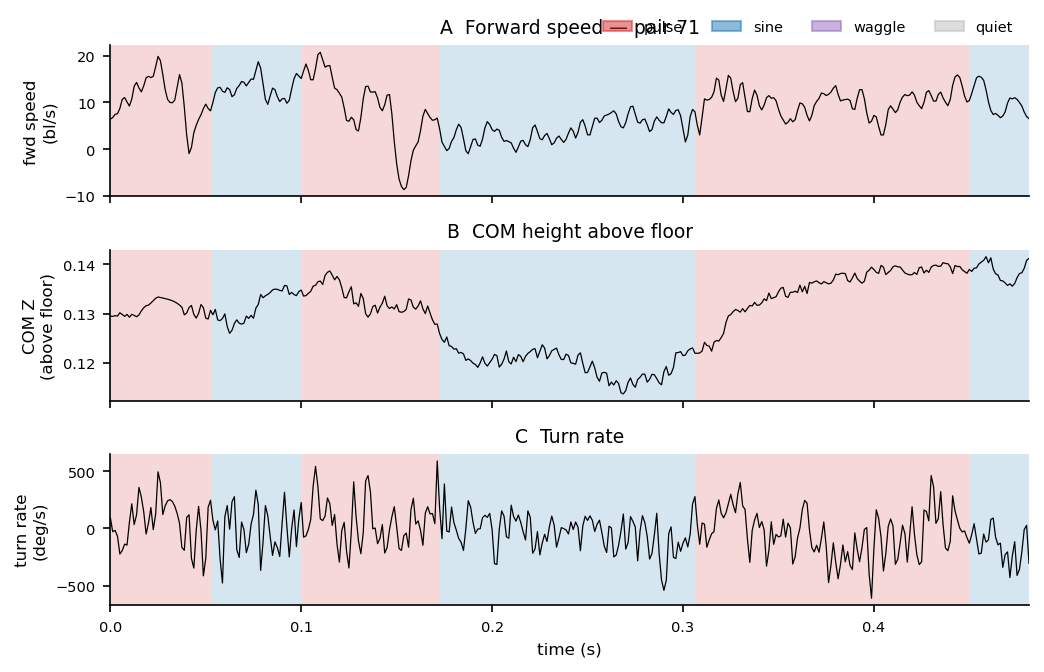

In [26]:
# --- Figure 3: Walking + COM height during song (same example bout) ---
ex = results[example_idx]
fs = loc_cfg.fs
T = ex['T']
t = np.arange(T) / fs
labels = ex['male_labels']

forward = np.asarray(ex['kin'].get('forward_speed_bl',
                                    ex['kin']['forward_speed']))
turn    = np.asarray(ex['kin']['turn_rate'])
com_z   = np.asarray(ex['com_z'])

def _shade_segments(ax, t, labels):
    """Shade the axes background by per-frame label runs."""
    T = len(labels)
    i = 0
    while i < T:
        j = i
        while j < T and labels[j] == labels[i]:
            j += 1
        ax.axvspan(t[i], t[min(j, T - 1)], color=SONG_COLORS[labels[i]],
                   alpha=0.18, lw=0)
        i = j

fig, axes = plt.subplots(3, 1, figsize=(7.0, 4.5), sharex=True)
_shade_segments(axes[0], t, labels)
axes[0].plot(t, forward, lw=0.6, color='k')
axes[0].set_ylabel('fwd speed\n(bl/s)')
axes[0].set_title(f'A  Forward speed — pair {example_idx}')

_shade_segments(axes[1], t, labels)
axes[1].plot(t, com_z, lw=0.6, color='k')
axes[1].set_ylabel('COM Z\n(above floor)')
axes[1].set_title('B  COM height above floor')

_shade_segments(axes[2], t, labels)
axes[2].plot(t, turn, lw=0.6, color='k')
axes[2].set_ylabel('turn rate\n(deg/s)')
axes[2].set_xlabel('time (s)')
axes[2].set_title('C  Turn rate')
axes[2].set_xlim(t[0], t[-1])

from matplotlib.patches import Patch
handles = [Patch(color=SONG_COLORS[k], label=k, alpha=0.5)
            for k in ('pulse', 'sine', 'waggle', 'quiet')]
fig.legend(handles=handles, loc='upper right', frameon=False,
            bbox_to_anchor=(0.98, 0.99), ncol=4)
plt.tight_layout()

out = FIG_DIR / 'fig3_walking_example.pdf'
plt.savefig(out)
print(f'saved {out}')
plt.show()


saved /home/eabe/Research/MyRepos/3d_tracking_dataset/figures/courtship/fig4_agg_song_locomotion.pdf


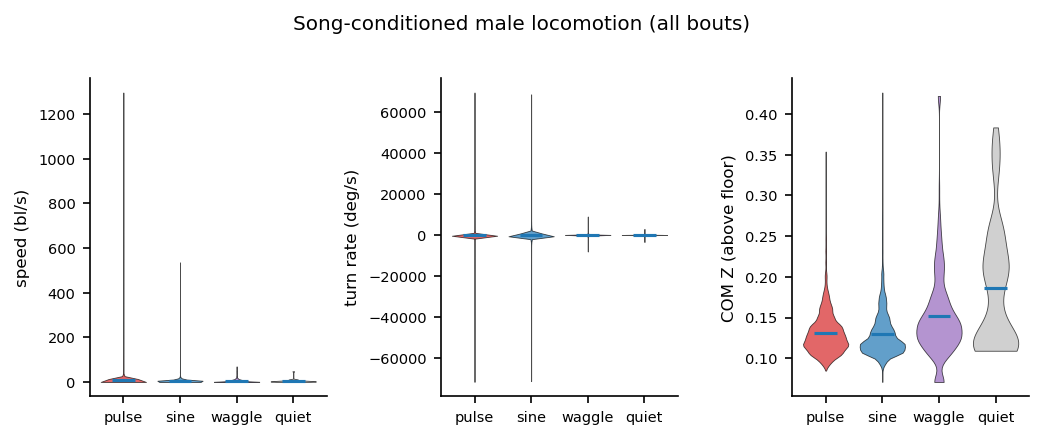

In [27]:
# --- Figure 4: Song-conditioned locomotion across ALL bouts ---
# Concatenate per-frame male metrics across bouts, keeping only frames
# where the male is valid (colocation-filtered already).
agg = defaultdict(lambda: defaultdict(list))  # metric → song → [values]
for r in results:
    valid = np.asarray(r['male_valid'], dtype=bool)
    if not valid.any():
        continue
    labels = np.asarray(r['male_labels'])[valid]
    metric_vals = {
        'speed_bl':  np.asarray(r['kin'].get('speed_bl', r['kin']['speed']))[valid],
        'turn_rate': np.asarray(r['kin']['turn_rate'])[valid],
        'com_z':     np.asarray(r['com_z'])[valid],
    }
    for m, v in metric_vals.items():
        for song in ('pulse', 'sine', 'waggle', 'quiet'):
            sel = (labels == song)
            if not sel.any():
                continue
            vs = v[sel]
            vs = vs[np.isfinite(vs)]
            if vs.size:
                agg[m][song].extend(vs.tolist())

METRIC_LABELS = {
    'speed_bl':  'speed (bl/s)',
    'turn_rate': 'turn rate (deg/s)',
    'com_z':     'COM Z (above floor)',
}
SONG_ORDER = ['pulse', 'sine', 'waggle', 'quiet']

fig, axes = plt.subplots(1, 3, figsize=(7.0, 2.8))
for ax, m in zip(axes, ['speed_bl', 'turn_rate', 'com_z']):
    datas = [np.asarray(agg[m].get(s, []), dtype=float) for s in SONG_ORDER]
    datas = [d[np.isfinite(d)] for d in datas]
    has_all = all(d.size > 10 for d in datas)
    if has_all:
        parts = ax.violinplot(datas, positions=range(len(SONG_ORDER)),
                              widths=0.8, showmeans=True, showextrema=False)
        for pc, s in zip(parts['bodies'], SONG_ORDER):
            pc.set_facecolor(SONG_COLORS[s]); pc.set_alpha(0.7)
            pc.set_edgecolor('k'); pc.set_linewidth(0.4)
    else:
        means = [float(np.mean(d)) if d.size else float('nan') for d in datas]
        sems  = [float(np.std(d) / np.sqrt(max(1, d.size))) if d.size else 0.0
                 for d in datas]
        ax.bar(range(len(SONG_ORDER)), means, yerr=sems,
               color=[SONG_COLORS[s] for s in SONG_ORDER],
               edgecolor='k', linewidth=0.4)
    ax.set_xticks(range(len(SONG_ORDER)))
    ax.set_xticklabels(SONG_ORDER, rotation=0)
    ax.set_ylabel(METRIC_LABELS[m])

fig.suptitle('Song-conditioned male locomotion (all bouts)', y=1.02)
plt.tight_layout()
out = FIG_DIR / 'fig4_agg_song_locomotion.pdf'
plt.savefig(out)
print(f'saved {out}')
plt.show()


saved /home/eabe/Research/MyRepos/3d_tracking_dataset/figures/courtship/fig5_per_bout_stacked.pdf


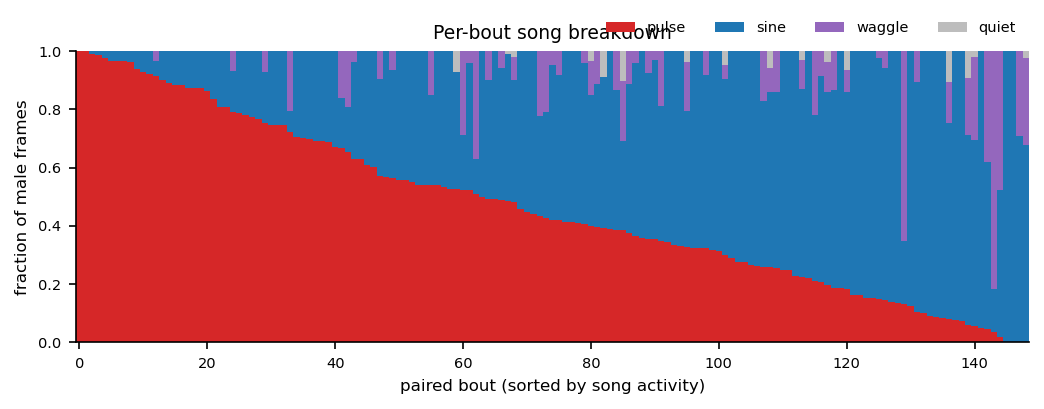

In [28]:
# --- Figure 5: Per-bout song breakdown (stacked bars) ---
df_sorted = df.sort_values(
    by=['frac_pulse', 'frac_sine', 'frac_waggle'], ascending=False
).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(7.0, 2.8))
x = np.arange(len(df_sorted))
bottom = np.zeros(len(df_sorted))
for song in ('pulse', 'sine', 'waggle', 'quiet'):
    vals = df_sorted[f'frac_{song}'].values
    ax.bar(x, vals, bottom=bottom, color=SONG_COLORS[song],
            width=1.0, edgecolor='none', label=song)
    bottom += vals
ax.set_xlim(-0.5, len(df_sorted) - 0.5)
ax.set_ylim(0, 1.0)
ax.set_xlabel('paired bout (sorted by song activity)')
ax.set_ylabel('fraction of male frames')
ax.set_title('Per-bout song breakdown')
ax.legend(frameon=False, loc='upper right', ncol=4, bbox_to_anchor=(1.0, 1.15))
plt.tight_layout()

out = FIG_DIR / 'fig5_per_bout_stacked.pdf'
plt.savefig(out)
print(f'saved {out}')
plt.show()


In [23]:
# --- Export per-bout results table ---
csv_path = FIG_DIR / 'per_bout_results.csv'
df.to_csv(csv_path, index=False)
print(f'wrote {csv_path}  ({len(df)} rows, {len(df.columns)} cols)')


wrote /home/eabe/Research/MyRepos/3d_tracking_dataset/figures/courtship/per_bout_results.csv  (149 rows, 52 cols)


In [24]:
# --- Text summary ---
n_pairs = len(df)
n_conf  = int((df['confidence'] >= 0.5).sum())
n_song  = int((df['criterion'] == 'song_fraction').sum())
n_disag = int(df['disagree_bodylen'].sum())

print(f'pairs processed        : {n_pairs}')
print(f'  male-ID confidence ≥0.5 : {n_conf}  ({100*n_conf/n_pairs:.1f}%)')
print(f'  song-based male ID      : {n_song}  ({100*n_song/n_pairs:.1f}%)')
print(f'  body-length disagreement: {n_disag}  ({100*n_disag/max(1,n_song):.1f}% of song-based calls)')
print()
print('median song fractions (male):')
for s in ('pulse', 'sine', 'waggle', 'quiet'):
    print(f'  {s:7s}: {df[f"frac_{s}"].median():.3f}')
print()
print('median locomotion (male):')
print(f'  mean speed      : {df["mean_speed_bl"].median():.3f} bl/s')
print(f'  mean COM Z      : {df["mean_com_z"].median():.3f}')
print(f'  walking fraction: {df["walking_fraction"].median():.3f}')


pairs processed        : 149
  male-ID confidence ≥0.5 : 38  (25.5%)
  song-based male ID      : 68  (45.6%)
  body-length disagreement: 16  (23.5% of song-based calls)

median song fractions (male):
  pulse  : 0.420
  sine   : 0.479
  waggle : 0.000
  quiet  : 0.000

median locomotion (male):
  mean speed      : 6.449 bl/s
  mean COM Z      : 0.124
  walking fraction: 1.000


## Figure captions

**Figure 1 — Male/female identification.** (A) Scatter of song fractions for fly0 vs fly1 in every paired bout, colored by which fly was assigned male. Points far from the diagonal reflect confident, song-driven assignments. (B) Body length distribution for the assigned male and female across all pairs (sanity check: males should be the smaller fly). (C) Histogram of male-ID confidence; the vertical dashed line marks the default threshold used for downstream filtering.

**Figure 2 — Song classification (example bout).** (A) Dominant-wing tip Z trace over time for the assigned male. (B) Spectrogram of the same trace with horizontal guides at the waggle / sine / pulse frequency band edges used by the classifier. (C) Per-frame label strip (pulse / sine / waggle / quiet).

**Figure 3 — Walking and COM height during song (same bout).** (A) Male forward speed in body-lengths per second, shaded by the per-frame song label. (B) Male COM Z above the per-bout estimated floor plane. (C) Male turn rate in deg/s.

**Figure 4 — Song-conditioned locomotion (aggregate).** Violin plots (or bars + SEM when sample sizes are small) of male walking speed, turn rate, and COM height, split by song label, concatenated across all bouts with a confident male assignment.

**Figure 5 — Per-bout song breakdown.** Stacked bars showing the fraction of male frames labeled pulse / sine / waggle / quiet for every paired bout, sorted by pulse+sine content. Quiet bouts sit on the right.
